Â# Learning Curves

**Loss Curve**
- Tends to decrease as epochs go by.
- After a certain amount of epochs, the value converges and we arrive at a minimum.

**Accuracy Curve**
- Tends to increase as epochs go by.
- After a certain amount of epochs, the value converges and we arrive at a maximum.

**Overfitting**
- Plotting training data against validation data can identify overfitting.
- Early stopping callback is useful stop training when test and validation performance curves start to diverge.

**Unstable Curves**
- Many curves will not be smooth, and require tuning hyperparameters like:
    - Selected optimizer
    - Learning rate
    - Batch size
    - Network architecture
    - Weight initialization

**Neural Networks**
- Well known for surpassing traditional machine learning techniques as the size of the dataset is increased.
- Checking whether collecting more data would increase generalization and accuracy may be beneficial.

## Multi-Class Classification with Digits Dataset

### Setup

In [13]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input
import matplotlib.pyplot as plt

# Load the digits dataset
digits = load_digits()
X, y = digits.data, digits.target

# Split into training and testing sets (30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

ValueError: Data must be 1-dimensional, got ndarray of shape (1797, 64) instead

### Instructions
1. Add a Dense layer of 16 neurons with relu activation and an input_shape that takes the total number of pixels of the 8x8 digit image.
2. Add a Dense layer with 10 outputs and softmax activation.
3. Compile your model with adam, categorical_crossentropy, and accuracy metrics.
4. Make sure your model works by predicting on X_train.

In [7]:
model = Sequential()

model.add(Input(shape=(64,))) # Updated approach to leveraging input_shape
model.add(Dense(16, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

pred = model.predict(X_train)
print(pred)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step
[[2.3293295e-10 1.6275558e-04 4.5389161e-08 ... 2.6919532e-03
  7.0159931e-06 9.9358225e-01]
 [4.1609948e-07 9.8277825e-01 9.7042472e-09 ... 1.6919715e-02
  3.4847511e-05 2.6654571e-04]
 [1.7052343e-10 1.3140068e-05 4.9406652e-09 ... 9.2739332e-01
  5.1373204e-06 6.5326452e-02]
 ...
 [1.4180847e-07 3.8569275e-01 2.6050253e-05 ... 4.6210667e-01
  5.4801552e-04 1.5151063e-01]
 [1.2296411e-05 6.2235570e-01 8.2926110e-09 ... 6.9979034e-02
  1.8723093e-03 3.0549791e-01]
 [2.1844710e-07 1.0124811e-03 2.8386480e-09 ... 9.7471839e-01
  2.8274928e-03 2.1353491e-02]]


### Instructions
1. Train your model for 60 epochs, using X_test and y_test as validation data.
2. Use plot_loss() passing loss and val_loss as extracted from the history attribute of the h_callback object.

In [11]:
def plot_loss(loss,val_loss):
  plt.figure()
  plt.plot(loss)
  plt.plot(val_loss)
  plt.title('Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Test'], loc='upper right')
  plt.show()

Epoch 1/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9988 - loss: 0.0215 - val_accuracy: 0.9722 - val_loss: 0.1417
Epoch 2/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9943 - loss: 0.0258 - val_accuracy: 0.9704 - val_loss: 0.1425
Epoch 3/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9993 - loss: 0.0194 - val_accuracy: 0.9704 - val_loss: 0.1414
Epoch 4/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9963 - loss: 0.0220 - val_accuracy: 0.9685 - val_loss: 0.1433
Epoch 5/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9991 - loss: 0.0225 - val_accuracy: 0.9704 - val_loss: 0.1420
Epoch 6/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9980 - loss: 0.0181 - val_accuracy: 0.9685 - val_loss: 0.1405
Epoch 7/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9996 - loss: 0.0161 - val_accuracy: 0.9704 - val_loss: 0.1412
Epoch 8/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9994 - loss: 0.0197 - val_accuracy: 0.9722 - val_loss:

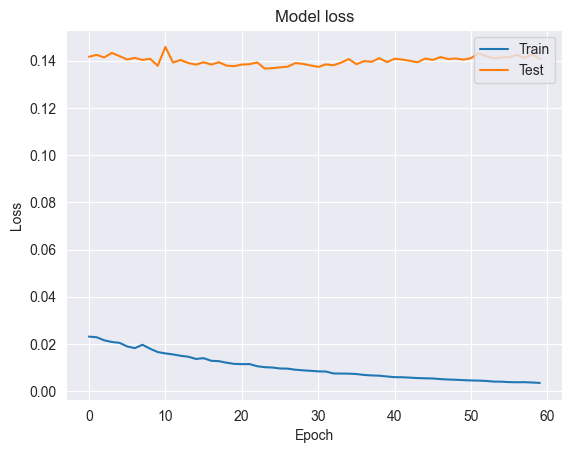

In [12]:
h_callback = model.fit(X_train, y_train_encoded, epochs=60, validation_data=(X_test, y_test_encoded))
plot_loss(h_callback.history['loss'], h_callback.history['val_loss'])